# 17 - Multimodal Transfer Hubs

After separating the transport modes, we want to find where a rider can move from one mode to another and whether those places are structurally unusual. We start with the strict GTFS definition—a stop ID served by at least two route types—but we also test a walking-distance definition because rail platforms and nearby bus bays usually have different IDs.

The analysis has three parts. First we stream scheduled calls by mode and station and rank transfer locations by mode count and service volume. Then we build mode-interdependence graphs under the strict and walkable definitions. Finally we join articulation-point and sampled-betweenness values and test whether interchange stations are more structurally important than ordinary stations.

Our main question is: **which recorded stations or nearby station groups connect transport layers, and does that multimodal position make them more likely to be network bottlenecks?**

We use the cleaned route, trip, and stop tables plus the node, articulation-point, and centrality outputs from notebooks 02-04. The raw `stop_times.txt` file supplies station calls. All station tables, interdependence tables, statistical results, maps, and the summary JSON go to `outputs/nb/17_multimodal_transfer_hubs/`.

## 1. Initialize the working environment

We find the repository root, change into it, and define the GTFS and output locations. The setup can clone the repository in Colab and installs only packages that are missing. All later paths depend on the values created here.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Load libraries and choose the transfer definition

We import the graph and data stack, statistical tests from `scipy.stats`, spatial search tools, and `csv` for the large-file scan. We create the stage folders and define the six mode labels used in the station memberships.

The main modeling parameter is `WALK_RADIUS_M = 150`. We treat stations within 150 meters as a two-minute walking neighborhood and take the union of their modes. Because that distance is a choice rather than a fact in the feed, we also calculate counts at 100 and 250 meters. The streaming result is cached; `FORCE_RESTREAM` controls whether we rebuild it.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scipy')

import csv, json, time
from collections import Counter, defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact

sns.set_theme(style='whitegrid', font_scale=1.05)

# A handful of rows in stop_times.txt are very long; raise the csv field limit up front.
csv.field_size_limit(10_000_000)

# --- Stage output folders -------------------------------------------------
STAGE = OUT / '17_multimodal_transfer_hubs'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# --- Cost knobs and analysis parameters ----------------------------------
FORCE_RESTREAM = False        # True -> always re-read the 816 MB feed (3-6 minutes)
PROGRESS_EVERY = 2_000_000    # progress print interval during the streaming pass
FIG_DPI = 150                 # figure resolution; drop to 90 for smaller files
WALK_RADIUS_M = 150           # "same interchange" radius for the spatial definition
WALK_RADIUS_SENSITIVITY = (100, 150, 250)   # radii re-tested in section 12
TOP_N_HUBS = 15               # rows in the printed / plotted hub rankings
MAP_ANNOTATE = 10             # hub labels drawn on the map
SEED = 42

# --- GTFS mode vocabulary (labels match notebooks 11 and 14) --------------
MODE_LABELS = {
    '0': 'tram/light rail',
    '2': 'rail',
    '3': 'bus',
    '5': 'cable tram',
    '8': 'trolleybus/taxi-coded',
    '715': 'demand/other bus',
}
UNKNOWN_MODE = 'unknown'

def mode_label(route_type):
    """Human-readable name for a GTFS route_type code; never raises, never drops."""
    code = str(route_type).strip()
    if code == '' or code.lower() == 'nan':
        return UNKNOWN_MODE
    return MODE_LABELS.get(code, f'other ({code})')

print('stage folder  :', STAGE)
print('modes tracked :', ', '.join(MODE_LABELS.values()))
print('walk radius   :', WALK_RADIUS_M, 'm')

stage folder  : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs
modes tracked : tram/light rail, rail, bus, cable tram, trolleybus/taxi-coded, demand/other bus
walk radius   : 150 m


## 3. Prepare Hebrew labels

The maps and hub rankings contain Hebrew station names, so we select a font with Hebrew glyphs. Raw Hebrew text already renders in the correct direction in this Matplotlib build, and the helper therefore leaves strings unchanged rather than applying another bidi reversal.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Load the graph and metric tables we need

We locate notebook outputs by their numeric prefixes and load cleaned routes, trips, and stops, the national node table, the articulation-point list, and the station centrality table. Every GTFS identifier is forced to a string so joins do not change its formatting.

The betweenness column is named `approx_betweenness` because it was calculated from sampled sources. We check that the required columns exist before continuing. A missing table or column stops the notebook rather than producing empty station groups that could still look plausible in a plot.

In [4]:
# --- Resolve earlier stages by their two-digit prefix ---------------------
def find_stage(prefix, notebook_hint):
    """Return an earlier stage's output folder, matched by its NN prefix."""
    matches = sorted(p for p in OUT.glob(f'{prefix}*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT}. '
            f'Run notebook {notebook_hint} first.')
    return matches[0]


def stage_artifact(prefix, filename, notebook_hint):
    """Path of `filename` inside stage `prefix`, or a FileNotFoundError that says why."""
    stage = find_stage(prefix, notebook_hint)
    direct = stage / 'tables' / filename
    if direct.exists():
        return direct
    hits = sorted(stage.rglob(filename))
    if not hits:
        raise FileNotFoundError(
            f'{filename} not found under {stage}. '
            f'Run notebook {notebook_hint} first - it writes {filename}.')
    return hits[0]


def read_gtfs_table(path):
    """GTFS ids are opaque codes: read every column as a string, keep blanks as ''."""
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding='utf-8-sig')


def read_metric_table(path):
    """Keep stop_id a string but let the metric columns stay numeric."""
    return pd.read_csv(path, dtype={'stop_id': str}, encoding='utf-8-sig')


routes = read_gtfs_table(stage_artifact('01', 'routes_clean.csv', '01_data_preparation'))
trips = read_gtfs_table(stage_artifact('01', 'trips_clean.csv', '01_data_preparation'))
stops = read_gtfs_table(stage_artifact('01', 'stops_clean.csv', '01_data_preparation'))
nodes = read_metric_table(stage_artifact('02', 'nodes.csv', '02_graph_construction'))
artic = read_metric_table(stage_artifact('03', 'articulation_points.csv',
                                         '03_descriptive_analysis'))
metrics = read_metric_table(stage_artifact('04', 'stop_metrics.csv',
                                           '04_centrality_analysis'))

# Column contracts, checked here so a rename upstream fails loudly and immediately.
for name, frame, needed in [
        ('routes_clean.csv', routes, ['route_id', 'route_type']),
        ('trips_clean.csv', trips, ['trip_id', 'route_id']),
        ('nodes.csv', nodes, ['stop_id', 'stop_name', 'lat', 'lon', 'region']),
        ('articulation_points.csv', artic, ['stop_id']),
        ('stop_metrics.csv', metrics, ['stop_id', 'degree', 'approx_betweenness'])]:
    missing = [c for c in needed if c not in frame.columns]
    if missing:
        raise KeyError(f'{name} is missing column(s) {missing} - re-run the notebook '
                       f'that produces it.')

BETWEENNESS = 'approx_betweenness'   # stage 04 names it this, NOT "betweenness"
articulation_ids = set(artic['stop_id'])

print(f'routes {len(routes):,} | trips {len(trips):,} | stops {len(stops):,}')
print(f'graph nodes {len(nodes):,} | centrality rows {len(metrics):,} | '
      f'articulation points {len(articulation_ids):,}')
print('route_type codes present:', sorted(set(routes['route_type'])))

routes 7,792 | trips 420,133 | stops 34,932
graph nodes 30,463 | centrality rows 30,463 | articulation points 900
route_type codes present: ['0', '2', '3', '5', '715', '8']


## 5. Build the `trip_id -> mode` lookup

We join trips to routes and map each trip to the route's mode label. The resulting dictionary has one entry per trip and lets the stop-time scan assign a mode with a single lookup when a trip block starts.

We print route and trip totals by mode and count any trip whose route is missing. On this feed all 420,133 trips map successfully. The distribution is highly uneven—412,544 bus trips versus much smaller secondary layers—which we need to remember when interpreting service-volume rankings.

In [5]:
# --- route_id -> route_type -> mode label, then trip_id -> mode label -----
route_type_of = dict(zip(routes['route_id'], routes['route_type']))
trip_mode = {trip: mode_label(route_type_of.get(route, ''))
             for trip, route in zip(trips['trip_id'], trips['route_id'])}
orphan_trips = sum(1 for route in trips['route_id'] if route not in route_type_of)

trips_typed = trips.assign(route_type=trips['route_id'].map(route_type_of).fillna(''))
mode_meta = pd.DataFrame({
    'routes': routes.groupby('route_type').size(),
    'trips': trips_typed.groupby('route_type').size(),
}).fillna(0).astype(int)
mode_meta.index.name = 'route_type'
mode_meta = mode_meta.reset_index()
mode_meta['mode_label'] = mode_meta['route_type'].map(mode_label)
mode_meta = mode_meta.sort_values('trips', ascending=False).reset_index(drop=True)

# Values verified in notebook 14; printed side by side so a broken join is obvious.
EXPECTED = {'3': (6796, 412544), '2': (962, 1188), '715': (14, 458),
            '0': (8, 2890), '8': (8, 47), '5': (4, 3006)}
print(f'trip_id -> mode entries: {len(trip_mode):,}')
print(f'trips whose route_id is missing from routes_clean.csv: {orphan_trips:,}')
print()
print('{:<6}{:<24}{:>9}{:>10}{:>12}'.format('code', 'mode', 'routes', 'trips', 'matches 14'))
for _, row in mode_meta.iterrows():
    exp = EXPECTED.get(row['route_type'])
    ok = 'n/a' if exp is None else ('yes' if (row['routes'], row['trips']) == exp else 'NO')
    print('{:<6}{:<24}{:>9,}{:>10,}{:>12}'.format(
        row['route_type'], row['mode_label'], row['routes'], row['trips'], ok))

trip_id -> mode entries: 420,133
trips whose route_id is missing from routes_clean.csv: 0

code  mode                       routes     trips  matches 14
3     bus                         6,796   412,544         yes
5     cable tram                      4     3,006         yes
0     tram/light rail                 8     2,890         yes
2     rail                          962     1,188         yes
715   demand/other bus               14       458         yes
8     trolleybus/taxi-coded           8        47         yes


## 6. Make sure the stop-times file is available

We download the roughly 816 MB `stop_times.txt` file only when it is missing and print the local size. This is the only external download needed here. The next cell streams the file so we never need to hold all 15.7 million rows in memory.

In [6]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 7. Count scheduled calls for each `(mode, station)` pair

We scan `stop_times.txt` line by line. At each trip boundary we look up the trip's mode, then increment the counter for that mode and stop ID on every row. A scheduled call is one trip stopping once at one station, so this gives a direct supply-volume measure split by mode.

The counter contains only about one row per observed mode-station pair, not one object per source row. We also track total rows, trip blocks, unmatched trips, and elapsed time. We do not parse arrival or departure times because this notebook only needs where a trip stops.

If the cached long table already exists, we reload it unless `FORCE_RESTREAM` is set. Either route should produce the same station-call totals.

In [7]:
# --- One pass over stop_times.txt, counting stop calls per (mode, stop) ---
STOP_MODE_CALLS = TABLES / 'stop_mode_calls.csv'
STREAM_STATS = STAGE / 'stream_stats.json'


def stream_stop_mode_calls(path, trip_mode, progress_every=PROGRESS_EVERY):
    """Scheduled stop calls per (mode, stop), in a single row-by-row pass.

    No time parsing is performed, so GTFS hours >= 24 are irrelevant here.
    Memory is O(modes x stops), never O(rows).
    """
    stop_calls = defaultdict(Counter)   # mode -> Counter[stop_id] = scheduled stop calls
    trips_observed = Counter()          # mode -> distinct trips met in the feed
    rows_by_mode = Counter()
    rows_read = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as handle:
        reader = csv.reader(handle)
        header = next(reader)
        for field in ('trip_id', 'stop_id'):
            if field not in header:
                raise ValueError(f'stop_times.txt has no "{field}" column')
        i_trip, i_stop = header.index('trip_id'), header.index('stop_id')

        prev_trip, mode = None, UNKNOWN_MODE
        for row in reader:
            rows_read += 1
            trip, stop = row[i_trip], row[i_stop]
            if trip != prev_trip:
                # New trip block: resolve the mode once per trip, not once per row.
                mode = trip_mode.get(trip, UNKNOWN_MODE)
                trips_observed[mode] += 1
                prev_trip = trip
            rows_by_mode[mode] += 1
            stop_calls[mode][stop] += 1
            if progress_every and rows_read % progress_every == 0:
                print(f'    {rows_read:,} rows | {time.time() - t0:,.0f}s')

    stats = {
        'rows_read': rows_read,
        'rows_by_mode': dict(rows_by_mode),
        'trips_observed': dict(trips_observed),
        'elapsed_seconds': round(time.time() - t0, 1),
    }
    return stop_calls, stats


newest_input = max(p.stat().st_mtime_ns for p in
                   (STOP_TIMES, DATA / 'routes.txt', DATA / 'trips.txt'))

# Notebook 14 has already computed exactly this table. Prefer that shared cache;
# retain this notebook's own cache and raw streaming as safe fallbacks.
shared_calls = shared_stats = None
try:
    shared_calls = stage_artifact('14', 'stop_mode_calls.csv', '14_multimodal_inventory')
    shared_stats = find_stage('14', '14_multimodal_inventory') / 'stream_stats.json'
    if not shared_stats.exists():
        shared_stats = None
except FileNotFoundError:
    pass

loaded_from_cache = False
if (not FORCE_RESTREAM and shared_calls is not None and shared_stats is not None
        and min(shared_calls.stat().st_mtime_ns, shared_stats.stat().st_mtime_ns) >= newest_input):
    try:
        _cached = pd.read_csv(shared_calls, dtype=str, keep_default_na=False,
                              encoding='utf-8-sig')
        required = {'mode_label', 'stop_id', 'stop_calls'}
        if not required.issubset(_cached.columns) or _cached.empty:
            raise ValueError('shared stop_mode_calls.csv has an invalid schema or is empty')
        with open(shared_stats, encoding='utf-8') as handle:
            stream_stats = json.load(handle)
        if int(stream_stats.get('rows_read', 0)) <= 0:
            raise ValueError('shared stream_stats.json is invalid')
        stop_calls = defaultdict(Counter)
        for m, s, c in zip(_cached['mode_label'], _cached['stop_id'], _cached['stop_calls']):
            stop_calls[m][s] = int(c)
        loaded_from_cache = True
        print('Re-using notebook 14 stop-mode counters:', shared_calls)
    except Exception as exc:
        print('Ignoring invalid notebook 14 cache:', exc)

local_cache_ready = (STOP_MODE_CALLS.exists() and STREAM_STATS.exists()
                     and min(STOP_MODE_CALLS.stat().st_mtime_ns,
                             STREAM_STATS.stat().st_mtime_ns) >= newest_input)
if not loaded_from_cache and local_cache_ready and not FORCE_RESTREAM:
    try:
        _cached = pd.read_csv(STOP_MODE_CALLS, dtype=str, keep_default_na=False,
                              encoding='utf-8-sig')
        required = {'mode_label', 'stop_id', 'stop_calls'}
        if not required.issubset(_cached.columns) or _cached.empty:
            raise ValueError('local stop_mode_calls.csv has an invalid schema or is empty')
        stop_calls = defaultdict(Counter)
        for m, s, c in zip(_cached['mode_label'], _cached['stop_id'], _cached['stop_calls']):
            stop_calls[m][s] = int(c)
        with open(STREAM_STATS, encoding='utf-8') as handle:
            stream_stats = json.load(handle)
        if int(stream_stats.get('rows_read', 0)) <= 0:
            raise ValueError('local stream_stats.json is invalid')
        loaded_from_cache = True
        print('Re-using this notebook\'s current (mode, stop) cache.')
    except Exception as exc:
        print('Ignoring invalid local cache:', exc)

if not loaded_from_cache:
    print('Streaming stop_times.txt (~15.7M rows) - cache missing, stale, or invalid ...')
    stop_calls, stream_stats = stream_stop_mode_calls(STOP_TIMES, trip_mode)

print('rows read       : {:,}'.format(stream_stats['rows_read']))
print('elapsed seconds :', stream_stats['elapsed_seconds'])
print()
print('{:<24}{:>16}{:>10}{:>9}'.format('mode', 'stop-time rows', 'trips', 'stops'))
for m, n_rows in sorted(stream_stats['rows_by_mode'].items(), key=lambda kv: -kv[1]):
    print('{:<24}{:>16,}{:>10,}{:>9,}'.format(
        m, n_rows, stream_stats['trips_observed'].get(m, 0), len(stop_calls.get(m, {}))))

Re-using notebook 14 stop-mode counters: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory/tables/stop_mode_calls.csv
rows read       : 15,711,624
elapsed seconds : 11.2

mode                      stop-time rows     trips    stops
bus                           15,608,376   412,544   30,170
tram/light rail                   70,333     2,890      138
rail                              14,601     1,188       67
cable tram                        10,830     3,006        9
demand/other bus                   7,390       458      153
trolleybus/taxi-coded                 94        47       10


## 8. Save the mode-station call table

We write one row per mode and stop with its scheduled-call count to `stop_mode_calls.csv`, plus the streaming counters to `stream_stats.json`. Saving this intermediate result makes later reruns fast and gives us the exact underlying counts if a hub ranking looks unexpected.

The CSV uses UTF-8 with a BOM so Hebrew remains readable outside the notebook.

In [8]:
# --- Persist the streaming result (also serves as the cache) --------------
stop_mode_calls = pd.DataFrame(
    [{'mode_label': m, 'stop_id': s, 'stop_calls': int(c)}
     for m, counter in stop_calls.items() for s, c in counter.items()]
)
_calls_tmp = STOP_MODE_CALLS.with_suffix('.csv.tmp')
stop_mode_calls.to_csv(_calls_tmp, index=False, encoding='utf-8-sig')
_calls_tmp.replace(STOP_MODE_CALLS)
_stats_tmp = STREAM_STATS.with_suffix('.json.tmp')
with open(_stats_tmp, 'w', encoding='utf-8') as handle:
    json.dump(stream_stats, handle, ensure_ascii=False, indent=2)
_stats_tmp.replace(STREAM_STATS)

print(f'{len(stop_mode_calls):,} (mode, stop) rows -> {STOP_MODE_CALLS}')
print(f'streaming counters                -> {STREAM_STATS}')
print(f'distinct stops seen in the feed   : {stop_mode_calls["stop_id"].nunique():,}')
stop_mode_calls.head()

30,547 (mode, stop) rows -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/stop_mode_calls.csv
streaming counters                -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/stream_stats.json
distinct stops seen in the feed   : 30,466


,mode_label,stop_id,stop_calls
0,bus,38725,1370
1,bus,15582,228
2,bus,15583,288
3,bus,16086,186
4,bus,16085,186


## 9. Collapse the calls to one row per station

We group the long table by stop ID and calculate the number of distinct modes, a sorted `|`-separated mode list, total scheduled calls, and one column of calls per mode. `is_multimodal` is true when the strict station ID has at least two modes.

We attach name, coordinates, and region from the national node table. A few served stops are not graph vertices because they never form a segment; we keep them and backfill attributes from the cleaned stop table.

On this run 30,466 stop IDs appear in scheduled calls. Only 81, or 0.27%, have two modes under the strict definition, and every one has the same combination: regular bus plus demand-responsive bus.

In [9]:
# --- One row per stop: which modes serve it, and how much service ---------
per_stop = (stop_mode_calls
            .groupby('stop_id')
            .agg(n_modes=('mode_label', 'nunique'),
                 modes_served=('mode_label', lambda s: '|'.join(sorted(set(s)))),
                 total_stop_calls=('stop_calls', 'sum'))
            .reset_index())

# Primary attributes: stage 02 nodes.csv. Fallback: stage 01 stops_clean.csv.
node_attrs = nodes[['stop_id', 'stop_name', 'lat', 'lon', 'region']].copy()

fallback = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon']].copy()
fallback['lat'] = pd.to_numeric(fallback['stop_lat'], errors='coerce')
fallback['lon'] = pd.to_numeric(fallback['stop_lon'], errors='coerce')
fallback['region'] = stops['region'] if 'region' in stops.columns else ''
fallback = fallback[['stop_id', 'stop_name', 'lat', 'lon', 'region']].drop_duplicates('stop_id')

hubs = per_stop.merge(node_attrs, on='stop_id', how='left')
missing_attrs = hubs['stop_name'].isna()
n_missing = int(missing_attrs.sum())
if n_missing:
    patch = fallback.set_index('stop_id')
    for column in ('stop_name', 'lat', 'lon', 'region'):
        hubs.loc[missing_attrs, column] = (hubs.loc[missing_attrs, 'stop_id']
                                           .map(patch[column]))
hubs['region'] = hubs['region'].fillna('')
hubs['stop_name'] = hubs['stop_name'].fillna('')
hubs['is_multimodal'] = hubs['n_modes'] >= 2
hubs = hubs.sort_values(['n_modes', 'total_stop_calls'], ascending=False).reset_index(drop=True)

print(f'stops in the feed                       : {len(hubs):,}')
print(f'  not vertices in stage 02 nodes.csv    : {n_missing:,} (attributes back-filled)')
print(f'  still without coordinates             : {int(hubs["lat"].isna().sum()):,}')
print(f'  multimodal (n_modes >= 2)             : {int(hubs["is_multimodal"].sum()):,}'
      f'  ({hubs["is_multimodal"].mean() * 100:.2f}% of stops)')
print()
print('stops by number of modes served:')
print(hubs['n_modes'].value_counts().sort_index().to_string())
print()
print('mode combinations actually observed at a single stop_id:')
print(hubs.loc[hubs['is_multimodal'], 'modes_served'].value_counts().to_string())

stops in the feed                       : 30,466
  not vertices in stage 02 nodes.csv    : 3 (attributes back-filled)
  still without coordinates             : 0
  multimodal (n_modes >= 2)             : 81  (0.27% of stops)

stops by number of modes served:
n_modes
1    30385
2       81

mode combinations actually observed at a single stop_id:
modes_served
bus|demand/other bus    81


## 10. Write the strict transfer-hub table

We save `transfer_hubs.csv` with one row per served station and the compact columns `stop_id, stop_name, lat, lon, region, n_modes, modes_served, is_multimodal`. Keeping single-mode stations is important because later tests need the comparison group and its denominator.

The extra fields—service volume, per-mode calls, walkable mode set, degree, betweenness, and articulation status—go into a companion details table after we calculate them. This keeps the basic station-membership table simple without losing the measurements used below.

In [10]:
# --- tables/transfer_hubs.csv (exact required schema) --------------------
REQUIRED_HUB_COLUMNS = ['stop_id', 'stop_name', 'lat', 'lon', 'region',
                        'n_modes', 'modes_served', 'is_multimodal']
transfer_hubs = hubs[REQUIRED_HUB_COLUMNS].copy()
transfer_hubs.to_csv(TABLES / 'transfer_hubs.csv', index=False, encoding='utf-8-sig')

assert list(transfer_hubs.columns) == REQUIRED_HUB_COLUMNS, 'schema drift in transfer_hubs.csv'
print(f'{len(transfer_hubs):,} rows -> {TABLES / "transfer_hubs.csv"}')
transfer_hubs.head(8)

30,466 rows -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/transfer_hubs.csv


,stop_id,stop_name,lat,lon,region,n_modes,modes_served,is_multimodal
0,11080,מחלף הרטוב,31.767298,34.997537,Jerusalem,2,bus|demand/other bus,True
1,11081,מחלף הרטוב,31.767124,34.997730,Jerusalem,2,bus|demand/other bus,True
2,11028,שדרות יגאל אלון/קניון שער העיר,31.756197,34.985749,Jerusalem,2,bus|demand/other bus,True
3,37273,שדרות יגאל אלון/הצבע,31.753943,34.994399,Jerusalem,2,bus|demand/other bus,True
4,41660,כביש 38/דולמיט,31.760419,34.987449,Jerusalem,2,bus|demand/other bus,True
5,11035,יגאל אלון/העלייה,31.755910,34.989729,Jerusalem,2,bus|demand/other bus,True
6,37274,שדרות יגאל אלון/הצבע,31.753714,34.994922,Jerusalem,2,bus|demand/other bus,True
7,11288,שד.יגאל אלון/הבנאי,31.754837,34.992821,Jerusalem,2,bus|demand/other bus,True


## 11. Rank strict hubs by mode count and service volume

We print the strict multimodal count, maximum number of modes on one stop ID, combined calls at those stops, and the busiest strict hubs. Mode count describes how many layers meet; total calls describes how much scheduled activity passes through the location.

Here `n_modes` never exceeds two, so service volume is the only meaningful ordering within the group. The per-mode call columns show that these are ordinary bus stops also used by demand-responsive service, not bus-rail or bus-light-rail terminals. The 81 stops account for only 0.20% of all scheduled calls.

In [11]:
# --- Two rankings of the multimodal stops --------------------------------
multimodal = hubs[hubs['is_multimodal']].copy()

calls_wide = (stop_mode_calls[stop_mode_calls['stop_id'].isin(set(multimodal['stop_id']))]
              .pivot_table(index='stop_id', columns='mode_label', values='stop_calls',
                           aggfunc='sum', fill_value=0)
              .reset_index())
ranked = (multimodal[['stop_id', 'stop_name', 'region', 'n_modes', 'modes_served',
                      'total_stop_calls']]
          .merge(calls_wide, on='stop_id', how='left')
          .sort_values(['n_modes', 'total_stop_calls'], ascending=False)
          .reset_index(drop=True))

print(f'multimodal stops: {len(multimodal):,}   max modes at one stop_id: '
      f'{int(hubs["n_modes"].max())}')
print(f'combined stop calls at multimodal stops: '
      f'{int(multimodal["total_stop_calls"].sum()):,} '
      f'({multimodal["total_stop_calls"].sum() / hubs["total_stop_calls"].sum() * 100:.2f}%'
      f' of all scheduled stop calls)')
print()
print(f'--- top {TOP_N_HUBS} multimodal stops by combined service volume ---')
print(ranked.head(TOP_N_HUBS).to_string(index=False))
print()
print('--- service volume of multimodal vs single-mode stops ---')
print(hubs.groupby('is_multimodal')['total_stop_calls']
      .agg(stops='size', median='median', mean='mean', total='sum').to_string())

multimodal stops: 81   max modes at one stop_id: 2
combined stop calls at multimodal stops: 31,111 (0.20% of all scheduled stop calls)

--- top 15 multimodal stops by combined service volume ---
stop_id                      stop_name    region  n_modes         modes_served  total_stop_calls  bus  demand/other bus
  11080                     מחלף הרטוב Jerusalem        2 bus|demand/other bus              2066 2042                24
  11081                     מחלף הרטוב Jerusalem        2 bus|demand/other bus              1982 1958                24
  11028 שדרות יגאל אלון/קניון שער העיר Jerusalem        2 bus|demand/other bus              1403 1356                47
  37273           שדרות יגאל אלון/הצבע Jerusalem        2 bus|demand/other bus              1275 1226                49
  41660                 כביש 38/דולמיט Jerusalem        2 bus|demand/other bus              1241 1170                71
  11035               יגאל אלון/העלייה Jerusalem        2 bus|demand/other bus       

## 12. Build the strict mode-interdependence graph

For every unordered pair of modes we count the intersection of their strict stop-ID sets. We save all 15 pairs, including zeros, to `mode_interdependence.csv`. Zero is a real result here: bus and rail share no station identifier in this feed.

The graph has one node per mode and a weighted edge only for a nonzero intersection. Under this definition it contains just one edge, between bus and demand-responsive bus with 81 shared IDs. That describes the feed's identifier scheme, but it is clearly too strict to represent real walking transfers.

In [12]:
# --- tables/mode_interdependence.csv (exact required schema) -------------
mode_stop_sets = {m: set(counter) for m, counter in stop_calls.items()}
observed_modes = sorted(mode_stop_sets, key=lambda m: -len(mode_stop_sets[m]))

interdependence = pd.DataFrame(
    [{'mode_a': a, 'mode_b': b,
      'shared_stops': len(mode_stop_sets[a] & mode_stop_sets[b])}
     for a, b in combinations(observed_modes, 2)]
).sort_values('shared_stops', ascending=False).reset_index(drop=True)
interdependence.to_csv(TABLES / 'mode_interdependence.csv', index=False,
                       encoding='utf-8-sig')

print('stops served, by mode:')
for m in observed_modes:
    print(f'  {m:<24}{len(mode_stop_sets[m]):>8,}')
print()
print(f'{len(interdependence)} mode pairs -> {TABLES / "mode_interdependence.csv"}')
print(interdependence.to_string(index=False))
print()
print('pairs sharing at least one stop_id: '
      f'{int((interdependence["shared_stops"] > 0).sum())} of {len(interdependence)}')

stops served, by mode:
  bus                       30,170
  demand/other bus             153
  tram/light rail              138
  rail                          67
  trolleybus/taxi-coded         10
  cable tram                     9

15 mode pairs -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/mode_interdependence.csv
               mode_a                mode_b  shared_stops
                  bus      demand/other bus            81
                  bus       tram/light rail             0
                  bus                  rail             0
                  bus trolleybus/taxi-coded             0
                  bus            cable tram             0
     demand/other bus       tram/light rail             0
     demand/other bus                  rail             0
     demand/other bus trolleybus/taxi-coded             0
     demand/other bus            cable tram             0
      tram/light rail                

## 13. Add a walking-distance transfer definition

We project longitude and latitude to approximate local meter coordinates and build a `cKDTree`. For each station we find all stop records within the chosen radius and take the union of their mode sets. If the union has at least two modes, we call the anchor station a walkable interchange stop.

We use a separate radius around each station instead of transitive clustering. Transitive merging could chain along a street of dense bus stops and create a “terminal” several hundred meters long. The local-neighborhood method asks only what a rider can reach from that specific point.

We repeat the count at 100, 150, and 250 meters. The groups contain 596, 866, and 1,364 stops respectively. At the main 150-meter radius, 2.84% of served stops have another mode within walking distance.

In [13]:
# --- Walkable (within-radius) mode sets ----------------------------------
def walkable_mode_sets(frame, radius_m):
    """Union of modes served within `radius_m` of each stop (the stop included).

    Local equirectangular projection; each stop keeps its own radius, so nothing
    chains transitively into over-large 'complexes'.
    """
    geo = frame.dropna(subset=['lat', 'lon'])
    if geo.empty:
        raise ValueError('No stop carries usable coordinates - check nodes.csv (stage 02).')
    lat0 = float(geo['lat'].mean())
    x = geo['lon'].to_numpy(dtype=float) * np.cos(np.deg2rad(lat0)) * 111_320.0
    y = geo['lat'].to_numpy(dtype=float) * 110_540.0
    points = np.column_stack([x, y])
    tree = cKDTree(points)
    neighbours = tree.query_ball_point(points, r=float(radius_m))
    own = [set(s.split('|')) if s else set() for s in geo['modes_served']]
    unions = [set().union(*(own[j] for j in idx)) if idx else set(own[i])
              for i, idx in enumerate(neighbours)]
    return pd.DataFrame({
        'stop_id': geo['stop_id'].to_numpy(),
        'walk_n_modes': [len(u) for u in unions],
        'walk_modes_served': ['|'.join(sorted(u)) for u in unions],
    })


# Sensitivity: how many interchange stops at each candidate radius?
print('{:>8}{:>22}{:>16}'.format('radius', 'interchange stops', 'share of stops'))
sensitivity = {}
for radius in WALK_RADIUS_SENSITIVITY:
    trial = walkable_mode_sets(hubs, radius)
    n_multi = int((trial['walk_n_modes'] >= 2).sum())
    sensitivity[radius] = n_multi
    print('{:>6}m{:>22,}{:>15.2f}%'.format(radius, n_multi, n_multi / len(hubs) * 100))

walk = walkable_mode_sets(hubs, WALK_RADIUS_M)
hubs = hubs.merge(walk, on='stop_id', how='left')
# Stops with no coordinates fall back to their own mode set.
no_geo = hubs['walk_n_modes'].isna()
hubs.loc[no_geo, 'walk_n_modes'] = hubs.loc[no_geo, 'n_modes']
hubs.loc[no_geo, 'walk_modes_served'] = hubs.loc[no_geo, 'modes_served']
hubs['walk_n_modes'] = hubs['walk_n_modes'].astype(int)
hubs['is_interchange'] = hubs['walk_n_modes'] >= 2

print()
print(f'stops with no coordinates (own mode set used): {int(no_geo.sum()):,}')
print(f'interchange stops at {WALK_RADIUS_M} m: {int(hubs["is_interchange"].sum()):,} '
      f'({hubs["is_interchange"].mean() * 100:.2f}% of stops)')
print()
print('walkable mode combinations (top 15):')
print(hubs.loc[hubs['is_interchange'], 'walk_modes_served']
      .value_counts().head(15).to_string())

  radius     interchange stops  share of stops
   100m                   596           1.96%
   150m                   866           2.84%
   250m                 1,364           4.48%

stops with no coordinates (own mode set used): 0
interchange stops at 150 m: 866 (2.84% of stops)

walkable mode combinations (top 15):
walk_modes_served
bus|tram/light rail               350
bus|rail                          283
bus|demand/other bus              118
bus|trolleybus/taxi-coded          37
bus|cable tram                     35
bus|cable tram|rail                16
bus|rail|tram/light rail           13
bus|demand/other bus|rail           6
bus|rail|trolleybus/taxi-coded      6
rail|tram/light rail                2


## 14. Build the walkable interdependence table

We count, for each mode pair, how many anchor stations have both modes in their 150-meter neighborhood. This is not a count of unique physical terminals: one rail station surrounded by several bus stops can contribute several anchors. It measures how much station-level access lies near both layers.

The contrast with the strict table is the point. Bus-light rail goes from zero shared IDs to 363 walkable anchors, bus-rail to 324, bus-cable tram to 51, and bus with the taxi-coded layer to 43. We save these counts separately in `mode_interdependence_walkable.csv` so the two definitions are never mixed.

In [14]:
# --- tables/mode_interdependence_walkable.csv ----------------------------
walk_sets = [set(s.split('|')) if s else set() for s in hubs['walk_modes_served']]
walk_pair_counts = Counter()
for modes_here in walk_sets:
    for pair in combinations(sorted(modes_here), 2):
        walk_pair_counts[pair] += 1

# observed_modes is ordered by size, so (a, b) is not necessarily alphabetical;
# walk_pair_counts is keyed on sorted pairs, so the lookup key must be sorted too.
interdependence_walk = pd.DataFrame(
    [{'mode_a': a, 'mode_b': b,
      'interchange_stops': walk_pair_counts.get(tuple(sorted((a, b))), 0)}
     for a, b in combinations(observed_modes, 2)]
).sort_values('interchange_stops', ascending=False).reset_index(drop=True)
interdependence_walk.to_csv(TABLES / 'mode_interdependence_walkable.csv', index=False,
                            encoding='utf-8-sig')

comparison = (interdependence
              .merge(interdependence_walk, on=['mode_a', 'mode_b'], how='outer')
              .fillna(0)
              .sort_values('interchange_stops', ascending=False)
              .reset_index(drop=True))
print(f'saved: {TABLES / "mode_interdependence_walkable.csv"}')
print(f'strict shared stop_ids vs walkable anchors within {WALK_RADIUS_M} m:')
print(comparison.to_string(index=False))

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/mode_interdependence_walkable.csv
strict shared stop_ids vs walkable anchors within 150 m:
               mode_a                mode_b  shared_stops  interchange_stops
                  bus       tram/light rail             0                363
                  bus                  rail             0                324
                  bus      demand/other bus            81                124
                  bus            cable tram             0                 51
                  bus trolleybus/taxi-coded             0                 43
                 rail            cable tram             0                 16
      tram/light rail                  rail             0                 15
     demand/other bus                  rail             0                  6
                 rail trolleybus/taxi-coded             0                  6
     demand/other bus    

## 15. Join structural importance measures

We merge the station groups with degree and `approx_betweenness` from notebook 04 and mark articulation points using notebook 03's list. These structural values were calculated on the combined graph without using mode labels, so they can serve as outcomes rather than circular definitions of multimodality.

The inner join removes served stops that are not actual graph vertices and therefore have no path-based metric. In this run 30,463 of 30,466 served stops remain. The analysis sample contains 81 strict multimodal stops, 864 walkable interchange graph nodes, and 900 articulation points.

In [15]:
# --- Join mode facts to the mode-blind structural measurements -----------
structural = metrics[['stop_id', 'degree', BETWEENNESS]].copy()
structural['is_articulation_point'] = structural['stop_id'].isin(articulation_ids)

analysis = hubs.merge(structural, on='stop_id', how='inner')
dropped = len(hubs) - len(analysis)

print(f'stops in the feed                     : {len(hubs):,}')
print(f'stops with structural measurements    : {len(analysis):,}')
print(f'dropped (not vertices of the graph)   : {dropped:,}')
print()
print('group sizes')
print(f'  strict multimodal (shared stop_id)  : {int(analysis["is_multimodal"].sum()):,}')
print(f'  walkable interchange ({WALK_RADIUS_M} m)      : {int(analysis["is_interchange"].sum()):,}')
print(f'  articulation points in the sample   : {int(analysis["is_articulation_point"].sum()):,}'
      f'  ({analysis["is_articulation_point"].mean() * 100:.2f}%)')
print()
print(analysis.groupby('is_multimodal')[[BETWEENNESS, 'degree']]
      .agg(['count', 'median', 'mean']).to_string())

stops in the feed                     : 30,466
stops with structural measurements    : 30,463
dropped (not vertices of the graph)   : 3

group sizes
  strict multimodal (shared stop_id)  : 81
  walkable interchange (150 m)      : 864
  articulation points in the sample   : 900  (2.95%)

              approx_betweenness                     degree                 
                           count    median      mean  count median      mean
is_multimodal                                                               
False                      30382  0.000046  0.000418  30382    3.0  3.392338
True                          81  0.000159  0.000673     81    5.0  5.901235


## 16. Test whether interchange stations are structurally different

We run the same two outcome tests for each transfer definition.

For sampled betweenness we use a two-sided Mann-Whitney U test because the distribution is extremely skewed and full of zeros. We report rank-biserial correlation and the common-language probability, not just the p-value.

For articulation status we use Fisher's exact test on the 2x2 group table because the strict group is small and its expected cut-point count is low. We also report the odds ratio, phi effect size, and Wilson intervals for both rates. Holm correction adjusts the four p-values as one family.

The strict group has higher betweenness with a small rank-biserial effect of 0.254, but its articulation odds ratio is 1.26 with negligible phi and a non-significant Fisher result. Walkable interchanges have lower betweenness on average (rank-biserial -0.187) but much higher cut-point odds; phi is still only 0.160, so the effect is small despite the tiny p-value.

In [16]:
# --- Test helpers: effect sizes and interval estimates -------------------
def wilson_interval(successes, total, z=1.96):
    """Wilson score interval for a proportion; sane at small n and rates near 0."""
    if total == 0:
        return (float('nan'), float('nan'))
    p = successes / total
    denom = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denom
    half = z * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2)) / denom
    return (max(0.0, centre - half), min(1.0, centre + half))


def holm_bonferroni(p_values):
    """Holm-Bonferroni family-wise-error adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    n = p.size
    order = np.argsort(p)
    scaled = p[order] * (n - np.arange(n))
    monotone = np.maximum.accumulate(scaled)
    out = np.empty(n)
    out[order] = np.clip(monotone, 0, 1)
    return out


def effect_size_words(magnitude, scale):
    """Plain-language label for an effect size, so the prose cannot overstate it."""
    cuts = {'rank_biserial': (0.15, 0.30, 0.50), 'phi': (0.10, 0.30, 0.50)}[scale]
    a = abs(magnitude)
    if a < cuts[0]:
        return 'negligible'
    if a < cuts[1]:
        return 'small'
    if a < cuts[2]:
        return 'medium'
    return 'large'


def betweenness_test(frame, flag, definition):
    """Mann-Whitney U on betweenness, with rank-biserial and CLES effect sizes."""
    group = frame[frame[flag]][BETWEENNESS].to_numpy(dtype=float)
    rest = frame[~frame[flag]][BETWEENNESS].to_numpy(dtype=float)
    u_stat, p_value = mannwhitneyu(group, rest, alternative='two-sided')
    pairs = len(group) * len(rest)
    cles = u_stat / pairs
    rank_biserial = 2 * cles - 1
    return {
        'definition': definition,
        'outcome': 'approx_betweenness',
        'test': 'Mann-Whitney U (two-sided)',
        'n_multimodal': len(group),
        'n_single_mode': len(rest),
        'statistic': float(u_stat),
        'p_value': float(p_value),
        'effect_size_name': 'rank_biserial',
        'effect_size': float(rank_biserial),
        'effect_size_reading': effect_size_words(rank_biserial, 'rank_biserial'),
        'cles_prob_multimodal_higher': float(cles),
        'median_multimodal': float(np.median(group)) if len(group) else float('nan'),
        'median_single_mode': float(np.median(rest)) if len(rest) else float('nan'),
        'mean_multimodal': float(np.mean(group)) if len(group) else float('nan'),
        'mean_single_mode': float(np.mean(rest)) if len(rest) else float('nan'),
    }


def articulation_test(frame, flag, definition):
    """Fisher exact (primary) + chi-square on the 2x2 group x cut-vertex table."""
    a = int(((frame[flag]) & (frame['is_articulation_point'])).sum())
    b = int(((frame[flag]) & (~frame['is_articulation_point'])).sum())
    c = int(((~frame[flag]) & (frame['is_articulation_point'])).sum())
    d = int(((~frame[flag]) & (~frame['is_articulation_point'])).sum())
    table = [[a, b], [c, d]]
    odds_ratio, p_fisher = fisher_exact(table)
    chi2, p_chi2, _, expected = chi2_contingency(table)
    n = a + b + c + d
    phi = float(np.sqrt(chi2 / n)) if n else float('nan')
    lo_m, hi_m = wilson_interval(a, a + b)
    lo_s, hi_s = wilson_interval(c, c + d)
    return {
        'definition': definition,
        'outcome': 'is_articulation_point',
        'test': 'Fisher exact (two-sided)',
        'n_multimodal': a + b,
        'n_single_mode': c + d,
        'statistic': float(odds_ratio),
        'p_value': float(p_fisher),
        'effect_size_name': 'phi',
        'effect_size': phi,
        'effect_size_reading': effect_size_words(phi, 'phi'),
        'odds_ratio': float(odds_ratio),
        'chi2': float(chi2),
        'p_value_chi2': float(p_chi2),
        'min_expected_cell': float(expected.min()),
        'rate_multimodal': a / (a + b) if (a + b) else float('nan'),
        'rate_single_mode': c / (c + d) if (c + d) else float('nan'),
        'rate_multimodal_ci': f'[{lo_m:.4f}, {hi_m:.4f}]',
        'rate_single_mode_ci': f'[{lo_s:.4f}, {hi_s:.4f}]',
        'cut_vertices_multimodal': a,
        'cut_vertices_single_mode': c,
    }


DEFINITIONS = [('is_multimodal', 'strict: shares a stop_id'),
               ('is_interchange', f'walkable: modes within {WALK_RADIUS_M} m')]

results = []
for flag, definition in DEFINITIONS:
    results.append(betweenness_test(analysis, flag, definition))
    results.append(articulation_test(analysis, flag, definition))

tests = pd.DataFrame(results)
tests['p_value_holm'] = holm_bonferroni(tests['p_value'])
tests['significant_holm_0.05'] = tests['p_value_holm'] < 0.05
tests.to_csv(TABLES / 'multimodal_structural_tests.csv', index=False, encoding='utf-8-sig')

pd.set_option('display.width', 200)
print(tests[['definition', 'outcome', 'test', 'n_multimodal', 'n_single_mode',
             'p_value', 'p_value_holm', 'effect_size_name', 'effect_size',
             'effect_size_reading']].to_string(index=False))
print()
for row in results:
    print(f'--- {row["definition"]} | {row["outcome"]} ---')
    if row['outcome'] == 'approx_betweenness':
        print(f'    median betweenness  : {row["median_multimodal"]:.3e} (multimodal) '
              f'vs {row["median_single_mode"]:.3e} (single-mode)')
        print(f'    P(multimodal higher): {row["cles_prob_multimodal_higher"]:.3f} '
              f'(0.500 = no difference)')
        print(f'    rank-biserial       : {row["effect_size"]:+.3f} '
              f'-> {row["effect_size_reading"]}')
    else:
        print(f'    cut-vertex rate     : {row["rate_multimodal"] * 100:.2f}% '
              f'{row["rate_multimodal_ci"]} vs {row["rate_single_mode"] * 100:.2f}% '
              f'{row["rate_single_mode_ci"]}')
        print(f'    odds ratio          : {row["odds_ratio"]:.2f}   '
              f'phi = {row["effect_size"]:.4f} -> {row["effect_size_reading"]}')
        print(f'    min expected cell   : {row["min_expected_cell"]:.2f} '
              f'(chi-square is unreliable below ~5; Fisher is the primary test)')
    print(f'    p = {row["p_value"]:.3g}  ->  Holm-adjusted p = '
          f'{float(tests.loc[(tests["definition"] == row["definition"]) & (tests["outcome"] == row["outcome"]), "p_value_holm"].iloc[0]):.3g}')
print()
print('saved:', TABLES / 'multimodal_structural_tests.csv')

                  definition               outcome                       test  n_multimodal  n_single_mode      p_value  p_value_holm effect_size_name  effect_size effect_size_reading
    strict: shares a stop_id    approx_betweenness Mann-Whitney U (two-sided)            81          30382 7.454733e-05  1.490947e-04    rank_biserial     0.254349               small
    strict: shares a stop_id is_articulation_point   Fisher exact (two-sided)            81          30382 5.179712e-01  5.179712e-01              phi     0.000403          negligible
walkable: modes within 150 m    approx_betweenness Mann-Whitney U (two-sided)           864          29599 6.053912e-21  1.816174e-20    rank_biserial    -0.187012               small
walkable: modes within 150 m is_articulation_point   Fisher exact (two-sided)           864          29599 6.297290e-84  2.518916e-83              phi     0.159963               small

--- strict: shares a stop_id | approx_betweenness ---
    median betweenness  :

## 17. Control the articulation comparison for degree

Interchange stations may differ simply because they have more neighbors. We divide stations into degree bands, build the group-by-articulation table within each band, and combine those tables with the Cochran-Mantel-Haenszel common odds ratio.

This asks whether multimodality remains associated with cut-point status after holding degree range roughly fixed. We also print every band so a pooled number cannot hide where the difference comes from.

For strict shared IDs, the crude odds ratio of 1.26 falls to 0.91 after adjustment. For 150-meter interchanges, the crude value is 9.11 and the degree-adjusted value is 7.57. The walkable association is therefore not just a consequence of these stations having higher degree.

In [17]:
# --- Cochran-Mantel-Haenszel: does the association survive degree control? ---
DEGREE_BANDS = [0, 2, 3, 4, 6, 10, 10_000]


def cmh_analysis(frame, flag, definition, bands=DEGREE_BANDS):
    """Degree-stratified 2x2 tables plus the CMH common odds ratio."""
    work = frame.copy()
    work['degree_band'] = pd.cut(work['degree'], bands)
    rows, num, den = [], 0.0, 0.0
    for band, part in work.groupby('degree_band', observed=True):
        a = int(((part[flag]) & (part['is_articulation_point'])).sum())
        b = int(((part[flag]) & (~part['is_articulation_point'])).sum())
        c = int(((~part[flag]) & (part['is_articulation_point'])).sum())
        d = int(((~part[flag]) & (~part['is_articulation_point'])).sum())
        n = a + b + c + d
        if n == 0:
            continue
        num += a * d / n
        den += b * c / n
        rows.append({'definition': definition, 'degree_band': str(band),
                     'stops': n, 'group_stops': a + b,
                     'rate_multimodal': (a / (a + b)) if (a + b) else float('nan'),
                     'rate_single_mode': (c / (c + d)) if (c + d) else float('nan')})
    common_or = (num / den) if den > 0 else float('nan')
    return pd.DataFrame(rows), float(common_or)


cmh_tables, cmh_summary = [], {}
for flag, definition in DEFINITIONS:
    band_table, common_or = cmh_analysis(analysis, flag, definition)
    cmh_summary[definition] = common_or
    cmh_tables.append(band_table)
    crude = float(tests.loc[(tests['definition'] == definition) &
                            (tests['outcome'] == 'is_articulation_point'),
                            'odds_ratio'].iloc[0])
    print(f'=== {definition} ===')
    print(f'    crude odds ratio                 : {crude:.2f}')
    print(f'    degree-adjusted (CMH) odds ratio : {common_or:.2f}')
    print(band_table.assign(
        rate_multimodal=lambda f: (f['rate_multimodal'] * 100).round(2),
        rate_single_mode=lambda f: (f['rate_single_mode'] * 100).round(2))
        [['degree_band', 'stops', 'group_stops', 'rate_multimodal', 'rate_single_mode']]
        .to_string(index=False))
    print()

cmh_table = pd.concat(cmh_tables, ignore_index=True)

=== strict: shares a stop_id ===
    crude odds ratio                 : 1.26
    degree-adjusted (CMH) odds ratio : 0.91
degree_band  stops  group_stops  rate_multimodal  rate_single_mode
     (0, 2]  13609            2             0.00              3.34
     (2, 3]   6769           14             0.00              1.63
     (3, 4]   4256           19             5.26              2.36
     (4, 6]   3724           20            10.00              2.46
    (6, 10]   1681           18             0.00              4.57
(10, 10000]    424            8             0.00             15.87

=== walkable: modes within 150 m ===
    crude odds ratio                 : 9.11
    degree-adjusted (CMH) odds ratio : 7.57
degree_band  stops  group_stops  rate_multimodal  rate_single_mode
     (0, 2]  13609          399            32.08              2.47
     (2, 3]   6769          123             4.88              1.56
     (3, 4]   4256           99             5.05              2.31
     (4, 6]   37

## 18. Save the full transfer-hub details

We now have both mode definitions and all structural columns, so we write them together to `transfer_hub_details.csv`. Each graph station gets strict and walkable mode counts, mode lists, scheduled calls, degree, sampled betweenness, and articulation status.

We sort by walkable mode count and service volume and print the busiest interchange anchors. This is the table we can filter for the combination we actually care about: a cut point near another mode with substantial scheduled service.

In [18]:
# --- tables/transfer_hub_details.csv -------------------------------------
details = analysis[['stop_id', 'stop_name', 'lat', 'lon', 'region',
                    'n_modes', 'modes_served', 'is_multimodal',
                    'walk_n_modes', 'walk_modes_served', 'is_interchange',
                    'total_stop_calls', 'degree', BETWEENNESS,
                    'is_articulation_point']].copy()
details = details.sort_values(['n_modes', 'walk_n_modes', 'total_stop_calls'],
                              ascending=False).reset_index(drop=True)
details.to_csv(TABLES / 'transfer_hub_details.csv', index=False, encoding='utf-8-sig')

print(f'{len(details):,} rows -> {TABLES / "transfer_hub_details.csv"}')
print()
print(f'--- top {TOP_N_HUBS} walkable interchange stops by service volume ---')
print(details[details['is_interchange']]
      .sort_values('total_stop_calls', ascending=False)
      .head(TOP_N_HUBS)[['stop_id', 'stop_name', 'region', 'walk_n_modes',
                         'walk_modes_served', 'total_stop_calls',
                         'is_articulation_point']]
      .to_string(index=False))

30,463 rows -> /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/tables/transfer_hub_details.csv

--- top 15 walkable interchange stops by service volume ---
stop_id                         stop_name    region  walk_n_modes        walk_modes_served  total_stop_calls  is_articulation_point
  13120       דרך זאב ז'בוטינסקי/מכון מור    Center             2      bus|tram/light rail              7393                  False
  48363      ת.רק''ל יהודית/דרך מנחם בגין    Center             2      bus|tram/light rail              6805                  False
  22099       ת. רק''ל בלינסון/קניון אבנת    Center             2      bus|tram/light rail              6538                   True
  13207  ת.רק''ל בן גוריון/דרך ז'בוטינסקי    Center             2      bus|tram/light rail              6366                  False
  14347 ת.רק''ל אהרונוביץ'/דרך ז'בוטינסקי    Center             2      bus|tram/light rail              6055                  False


## 19. Plot the hub inventory

The first panel compares station counts by number of modes under strict and walkable definitions on a log scale. The second ranks strict hubs by scheduled calls, and the third shows each region's share of walkable interchange stops.

We use shares for the regional comparison because the number of stations differs greatly by region. The figure is mainly a compact check that the two definitions produce genuinely different groups rather than slightly different counts of the same locations.

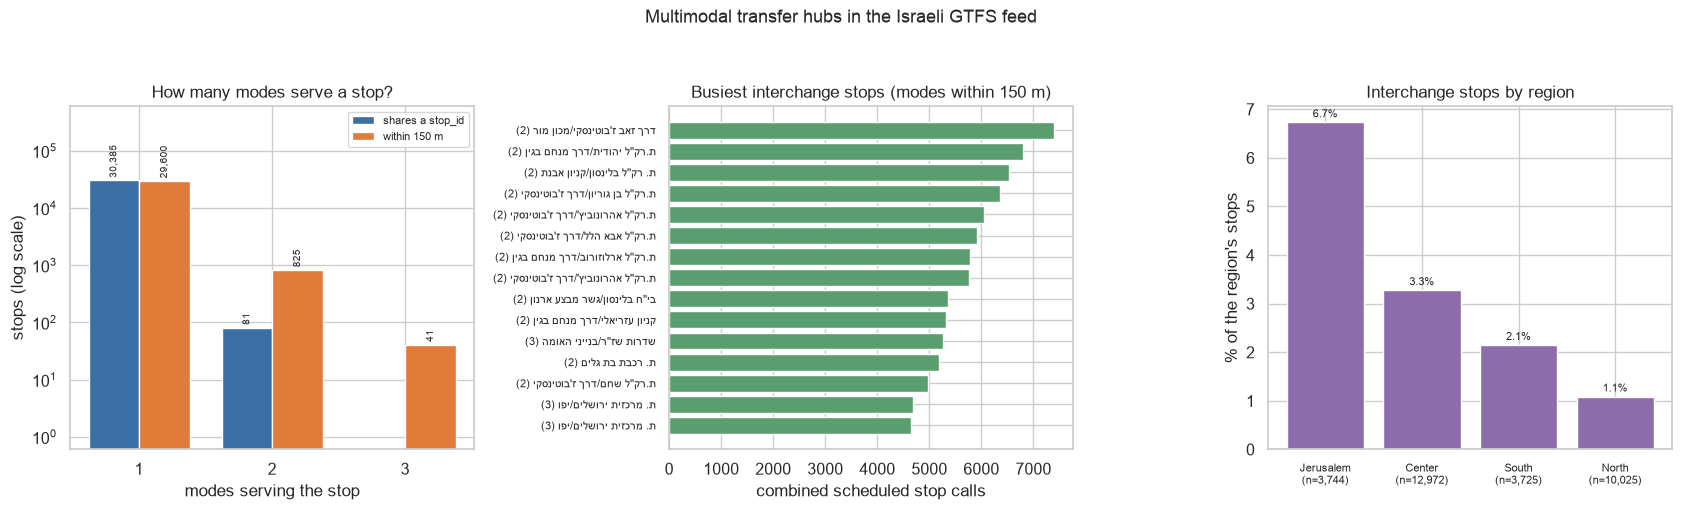

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/figures/hub_inventory.png


In [19]:
# --- Figure 1: hub inventory ---------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# Panel 1: distribution of modes per stop, both definitions
ax = axes[0]
strict_counts = hubs['n_modes'].value_counts().sort_index()
walk_counts = hubs['walk_n_modes'].value_counts().sort_index()
levels = sorted(set(strict_counts.index) | set(walk_counts.index))
x = np.arange(len(levels))
width = 0.38
bars1 = ax.bar(x - width / 2, [strict_counts.get(k, 0) for k in levels], width,
               label='shares a stop_id', color='#3b6ea5')
bars2 = ax.bar(x + width / 2, [walk_counts.get(k, 0) for k in levels], width,
               label=f'within {WALK_RADIUS_M} m', color='#e07b39')
for bars in (bars1, bars2):
    ax.bar_label(bars, labels=[f'{int(b.get_height()):,}' if b.get_height() else ''
                               for b in bars], fontsize=7, padding=2, rotation=90)
ax.set_yscale('log')
ax.set_ylim(0.6, max(strict_counts.max(), walk_counts.max()) * 20)
ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_xlabel('modes serving the stop')
ax.set_ylabel('stops (log scale)')
ax.set_title('How many modes serve a stop?')
ax.legend(fontsize=8)

# Panel 2: top hubs by combined service volume
ax = axes[1]
top = (details[details['is_interchange']]
       .sort_values('total_stop_calls', ascending=False)
       .head(TOP_N_HUBS)
       .iloc[::-1])
ax.barh(range(len(top)), top['total_stop_calls'], color='#5a9e6f')
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f'{name} ({n})' for name, n in
                    zip(top['stop_name'], top['walk_n_modes'])], fontsize=8)
ax.set_xlabel('combined scheduled stop calls')
ax.set_title(f'Busiest interchange stops (modes within {WALK_RADIUS_M} m)')

# Panel 3: interchange share by region
ax = axes[2]
by_region = (hubs.assign(region=hubs['region'].replace('', 'unknown'))
             .groupby('region')
             .agg(stops=('stop_id', 'size'),
                  interchange=('is_interchange', 'sum'),
                  multimodal=('is_multimodal', 'sum')))
by_region['interchange_share'] = by_region['interchange'] / by_region['stops'] * 100
by_region = by_region.sort_values('interchange_share', ascending=False)
bars = ax.bar(range(len(by_region)), by_region['interchange_share'], color='#8d6cab')
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in by_region['interchange_share']],
             fontsize=8, padding=2)
ax.set_xticks(range(len(by_region)))
ax.set_xticklabels([f'{idx}\n(n={int(row.stops):,})'
                    for idx, row in by_region.iterrows()], fontsize=8)
ax.set_ylabel("% of the region's stops")
ax.set_title('Interchange stops by region')

fig.suptitle('Multimodal transfer hubs in the Israeli GTFS feed', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES / 'hub_inventory.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'hub_inventory.png')

## 20. Draw the two interdependence graphs

We make one graph from shared stop IDs and one from 150-meter neighborhoods using the same circular layout. Node size reflects each mode's station count on a log scale, and nonzero edge width reflects the square root of the overlap count.

The strict graph has six nodes and one edge. The walkable graph has six nodes, nine edges, and is connected. Its main shape is centered on bus because every secondary mode has many more nearby bus anchors than direct links to another secondary mode.

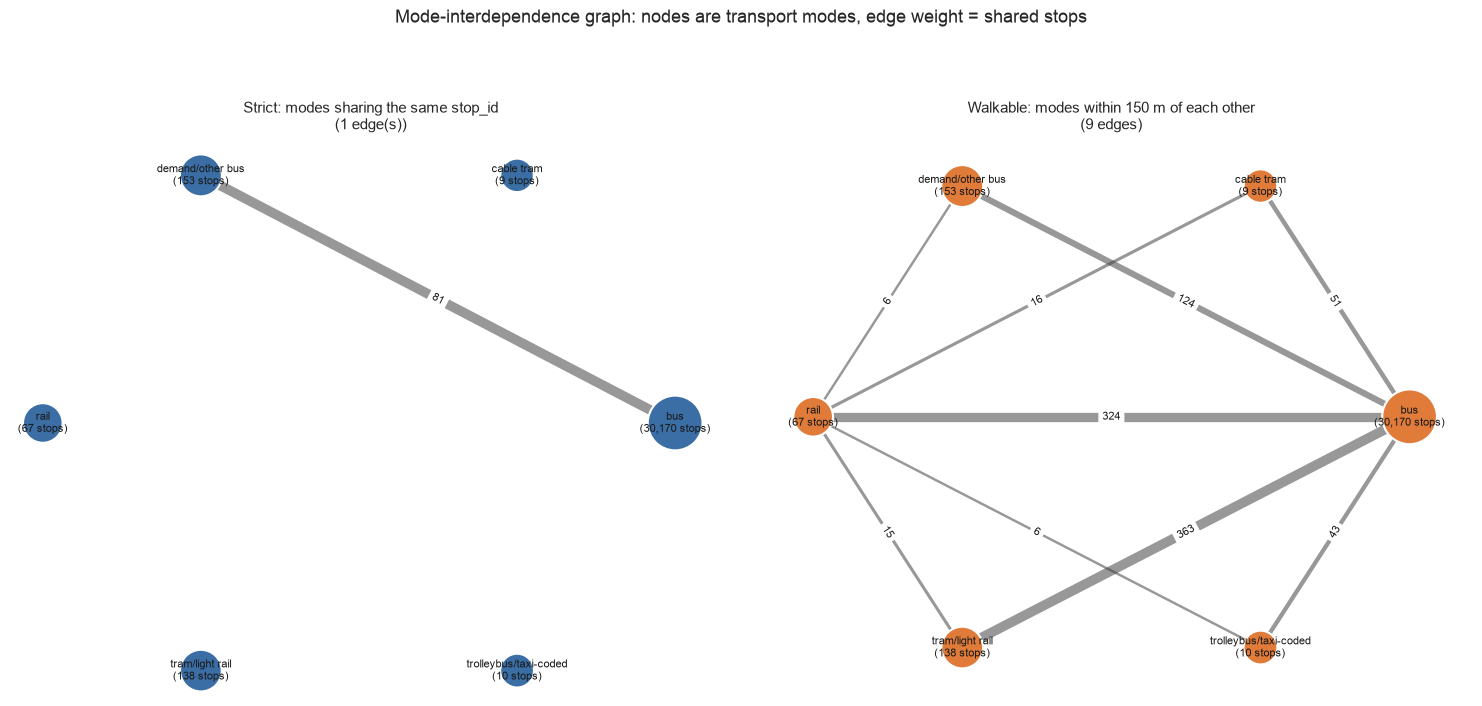

strict graph : 6 nodes, 1 edges, connected = False
walkable graph: 6 nodes, 9 edges, connected = True
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/figures/mode_interdependence_graph.png


In [20]:
# --- Figure 2: mode interdependence, both definitions --------------------
def draw_mode_graph(ax, pair_weights, node_sizes, title, colour):
    G = nx.Graph()
    for m in observed_modes:
        G.add_node(m, stops=node_sizes.get(m, 0))
    for (a, b), w in pair_weights.items():
        if w > 0:
            G.add_edge(a, b, weight=w)
    pos = nx.circular_layout(sorted(G.nodes()))
    sizes = [300 + 1400 * np.log10(1 + G.nodes[n]['stops']) / 5 for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=sizes, node_color=colour,
                           edgecolors='white', linewidths=1.5)
    if G.number_of_edges():
        weights = [G[u][v]['weight'] for u, v in G.edges()]
        widths = [1.0 + 6.0 * np.sqrt(w) / np.sqrt(max(weights)) for w in weights]
        nx.draw_networkx_edges(G, pos, ax=ax, width=widths, alpha=0.55,
                               edge_color='#444444')
        nx.draw_networkx_edge_labels(
            G, pos, ax=ax, font_size=8,
            edge_labels={(u, v): f'{G[u][v]["weight"]:,}' for u, v in G.edges()})
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8,
                            labels={n: f'{n}\n({G.nodes[n]["stops"]:,} stops)'
                                    for n in G.nodes()})
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    return G


strict_weights = {(r.mode_a, r.mode_b): int(r.shared_stops)
                  for r in interdependence.itertuples()}
walk_weights = {(r.mode_a, r.mode_b): int(r.interchange_stops)
                for r in interdependence_walk.itertuples()}
strict_sizes = {m: len(s) for m, s in mode_stop_sets.items()}

n_strict_edges = sum(1 for w in strict_weights.values() if w > 0)
n_walk_edges = sum(1 for w in walk_weights.values() if w > 0)

fig, axes = plt.subplots(1, 2, figsize=(15, 7.2))
G_strict = draw_mode_graph(axes[0], strict_weights, strict_sizes,
                           'Strict: modes sharing the same stop_id\n'
                           f'({n_strict_edges} edge(s))',
                           '#3b6ea5')
G_walk = draw_mode_graph(axes[1], walk_weights, strict_sizes,
                         f'Walkable: modes within {WALK_RADIUS_M} m of each other\n'
                         f'({n_walk_edges} edges)',
                         '#e07b39')
fig.suptitle('Mode-interdependence graph: nodes are transport modes, '
             'edge weight = shared stops', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'mode_interdependence_graph.png', dpi=FIG_DPI)
plt.show()

print('strict graph : {} nodes, {} edges, connected = {}'.format(
    G_strict.number_of_nodes(), G_strict.number_of_edges(),
    nx.is_connected(G_strict) if G_strict.number_of_nodes() else False))
print('walkable graph: {} nodes, {} edges, connected = {}'.format(
    G_walk.number_of_nodes(), G_walk.number_of_edges(),
    nx.is_connected(G_walk) if G_walk.number_of_nodes() else False))
print('saved:', FIGURES / 'mode_interdependence_graph.png')

## 21. Map strict and walkable hubs

We draw all station coordinates in gray, then overlay strict multimodal IDs and walkable interchange anchors. A third panel gives a closer regional view, and the busiest locations are labeled. The aspect ratio is corrected for latitude.

The strict group follows the geography of demand-responsive bus overlap. The walkable group instead follows metropolitan corridors and the rail axis. This map is our visual check that the spatial definition finds recognizable interchange areas rather than random nearby coordinates.

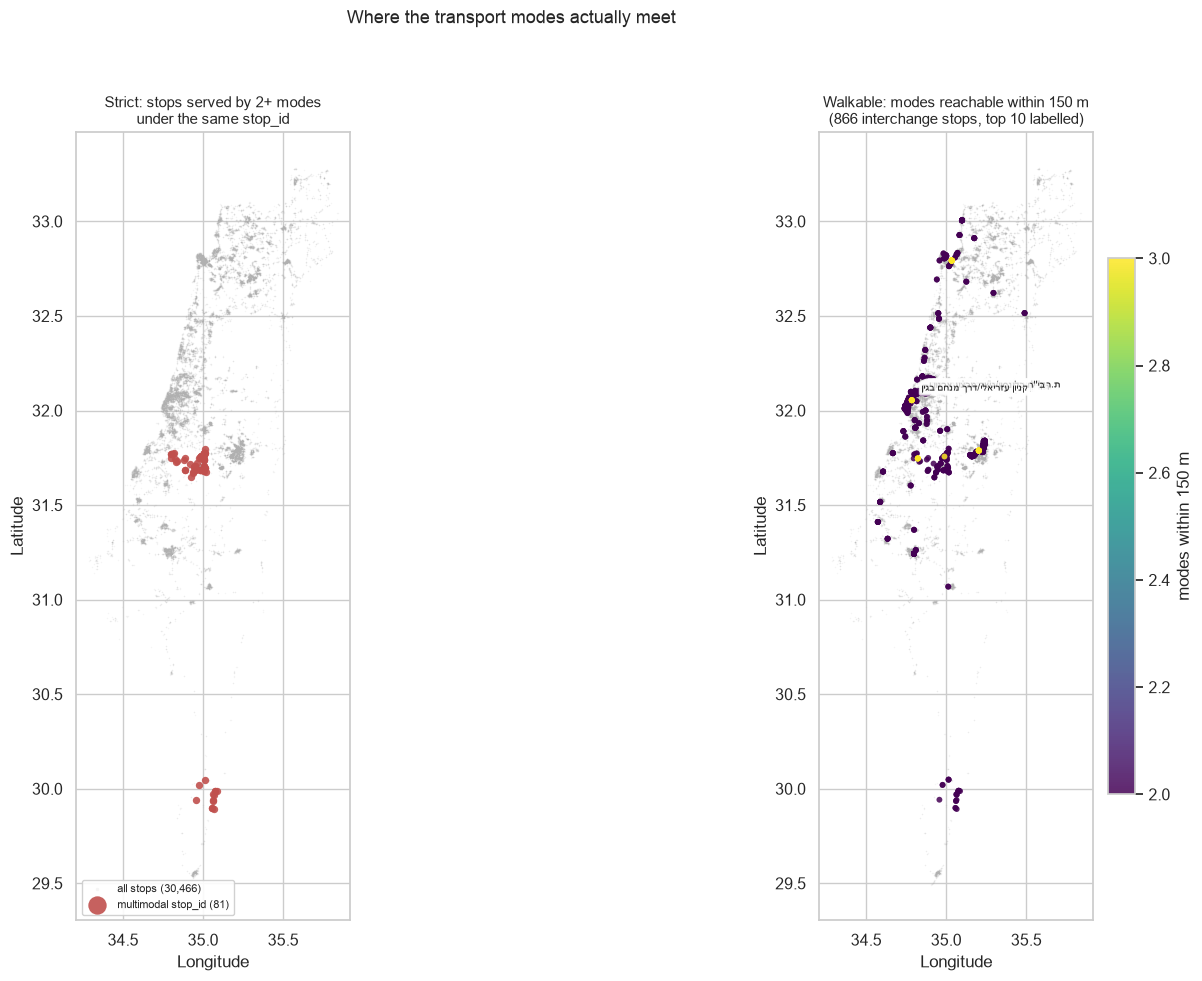

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/figures/transfer_hub_map.png


In [21]:
# --- Figure 3: hub geography ---------------------------------------------
geo = hubs.dropna(subset=['lat', 'lon'])
aspect = 1 / np.cos(np.deg2rad(float(geo['lat'].mean())))

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Left: strict multimodal stops
ax = axes[0]
ax.scatter(geo['lon'], geo['lat'], s=1, alpha=0.12, linewidths=0, color='#b0b0b0',
           label=f'all stops ({len(geo):,})')
strict_geo = geo[geo['is_multimodal']]
ax.scatter(strict_geo['lon'], strict_geo['lat'], s=28, alpha=0.9, linewidths=0,
           color='#c0504d', label=f'multimodal stop_id ({len(strict_geo):,})')
ax.set_aspect(aspect)
ax.set_title('Strict: stops served by 2+ modes\nunder the same stop_id', fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=8, markerscale=2.5, framealpha=0.9)

# Right: walkable interchange stops, coloured by walkable mode count
ax = axes[1]
ax.scatter(geo['lon'], geo['lat'], s=1, alpha=0.12, linewidths=0, color='#b0b0b0')
inter_geo = geo[geo['is_interchange']].sort_values('walk_n_modes')
scatter = ax.scatter(inter_geo['lon'], inter_geo['lat'], s=18, alpha=0.85, linewidths=0,
                     c=inter_geo['walk_n_modes'], cmap='viridis')
cbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('modes within {} m'.format(WALK_RADIUS_M))

label_me = (details[details['is_interchange']]
            .dropna(subset=['lat', 'lon'])
            .sort_values('total_stop_calls', ascending=False)
            .head(MAP_ANNOTATE))
for _, row in label_me.iterrows():
    ax.annotate(row['stop_name'], (row['lon'], row['lat']),
                textcoords='offset points', xytext=(6, 4), fontsize=7,
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.75))
ax.set_aspect(aspect)
ax.set_title(f'Walkable: modes reachable within {WALK_RADIUS_M} m\n'
             f'({len(inter_geo):,} interchange stops, top {MAP_ANNOTATE} labelled)',
             fontsize=11)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

fig.suptitle('Where the transport modes actually meet', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIGURES / 'transfer_hub_map.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'transfer_hub_map.png')

## 22. Plot the structural comparisons

The left panel shows group betweenness distributions after applying `log10(value + epsilon)` for visibility. The statistical test still uses raw values, so the plotting transform cannot change its ranks. The right panel shows articulation rates with 95% Wilson intervals.

We annotate odds ratios and Holm-adjusted p-values from the test table rather than recomputing numbers inside the plotting code. The strict and walkable definitions point in different directions, which is exactly why both panels and both definitions need to stay visible.

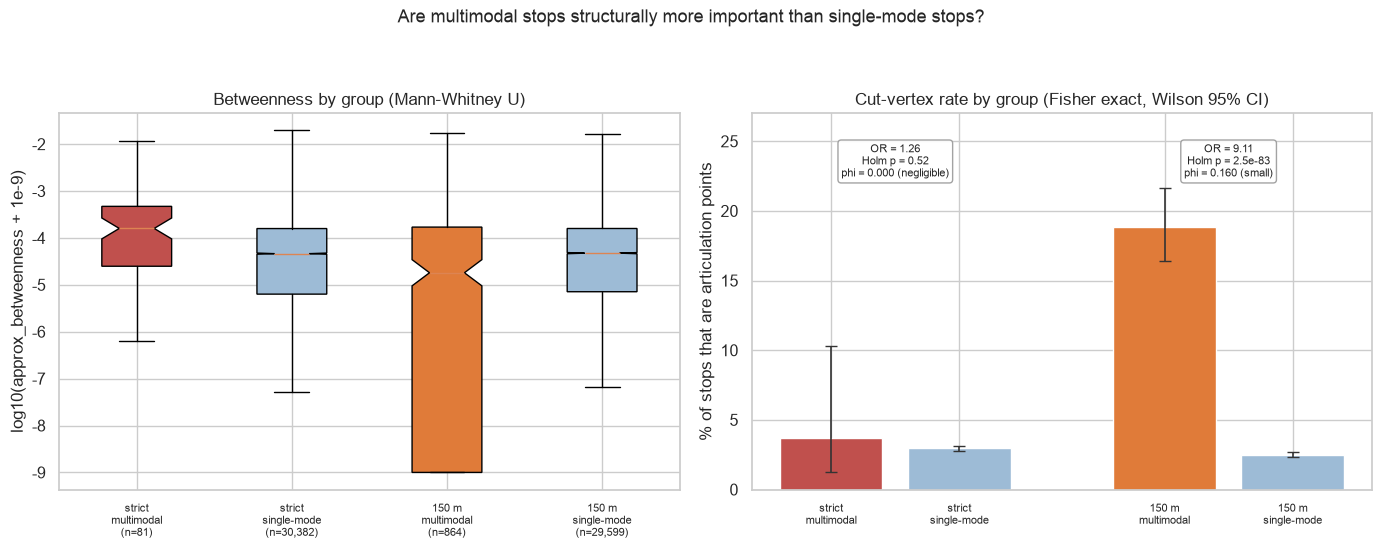

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/figures/structural_importance.png


In [22]:
# --- Figure 4: structural importance, by definition ----------------------
EPS = 1e-9
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))

# Left: betweenness distributions
ax = axes[0]
box_data, box_labels = [], []
for flag, definition in DEFINITIONS:
    for is_group, tag in [(True, 'multimodal'), (False, 'single-mode')]:
        values = analysis.loc[analysis[flag] == is_group, BETWEENNESS].to_numpy(dtype=float)
        box_data.append(np.log10(values + EPS))
        short = 'strict' if flag == 'is_multimodal' else f'{WALK_RADIUS_M} m'
        box_labels.append(f'{short}\n{tag}\n(n={len(values):,})')
bp = ax.boxplot(box_data, showfliers=False, notch=True, patch_artist=True)
ax.set_xticks(range(1, len(box_labels) + 1))
ax.set_xticklabels(box_labels)
for patch, colour in zip(bp['boxes'], ['#c0504d', '#9dbbd6', '#e07b39', '#9dbbd6']):
    patch.set_facecolor(colour)
ax.set_ylabel('log10(approx_betweenness + 1e-9)')
ax.set_title('Betweenness by group (Mann-Whitney U)')
ax.tick_params(axis='x', labelsize=8)

# Right: articulation-point rates with Wilson intervals
ax = axes[1]
positions, heights, errors, labels, colours = [], [], [], [], []
for k, (flag, definition) in enumerate(DEFINITIONS):
    row = tests[(tests['definition'] == definition) &
                (tests['outcome'] == 'is_articulation_point')].iloc[0]
    for j, (rate, n_group, tag, colour) in enumerate([
            (row['rate_multimodal'], row['n_multimodal'], 'multimodal',
             '#c0504d' if k == 0 else '#e07b39'),
            (row['rate_single_mode'], row['n_single_mode'], 'single-mode', '#9dbbd6')]):
        successes = int(round(rate * n_group))
        lo, hi = wilson_interval(successes, int(n_group))
        positions.append(k * 2.6 + j)
        heights.append(rate * 100)
        errors.append([(rate - lo) * 100, (hi - rate) * 100])
        short = 'strict' if flag == 'is_multimodal' else f'{WALK_RADIUS_M} m'
        labels.append(f'{short}\n{tag}')
        colours.append(colour)
err = np.array(errors).T
ax.bar(positions, heights, color=colours, width=0.8,
       yerr=err, capsize=4, error_kw={'ecolor': '#333333', 'lw': 1.2})
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('% of stops that are articulation points')
ax.set_title('Cut-vertex rate by group (Fisher exact, Wilson 95% CI)')
top_y = max(h + e for h, e in zip(heights, err[1])) * 1.25
ax.set_ylim(0, top_y)
for k, (flag, definition) in enumerate(DEFINITIONS):
    row = tests[(tests['definition'] == definition) &
                (tests['outcome'] == 'is_articulation_point')].iloc[0]
    ax.text(k * 2.6 + 0.5, top_y * 0.92,
            f'OR = {row["odds_ratio"]:.2f}\nHolm p = {row["p_value_holm"]:.2g}\n'
            f'phi = {row["effect_size"]:.3f} ({row["effect_size_reading"]})',
            ha='center', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#999999', alpha=0.9))

fig.suptitle('Are multimodal stops structurally more important than single-mode stops?',
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.savefig(FIGURES / 'structural_importance.png', dpi=FIG_DPI)
plt.show()
print('saved:', FIGURES / 'structural_importance.png')

## 23. Save the machine-readable summary

We gather the mode inventory, strict and walkable hub counts, both interdependence structures, radius sensitivity, test statistics, effect sizes, degree-adjusted odds ratios, and leading service-volume hubs in `multimodal_summary.json`.

The JSON uses native-number conversion for NumPy values and keeps Hebrew text unescaped. This gives the next notebooks one compact artifact without requiring them to reconstruct groups or tests from several CSV files.

In [23]:
# --- multimodal_summary.json ---------------------------------------------
top_records = (details.sort_values(['walk_n_modes', 'total_stop_calls'], ascending=False)
               .head(TOP_N_HUBS)[['stop_id', 'stop_name', 'region', 'n_modes',
                                  'modes_served', 'walk_n_modes', 'walk_modes_served',
                                  'total_stop_calls', 'is_articulation_point']]
               .to_dict(orient='records'))

summary = {
    'stage': '17_multimodal_transfer_hubs',
    'walk_radius_m': WALK_RADIUS_M,
    'stops_in_feed': int(len(hubs)),
    'stops_with_structural_metrics': int(len(analysis)),
    'stop_time_rows_read': int(stream_stats['rows_read']),
    'modes': {
        m: {'route_type': next((r['route_type'] for _, r in mode_meta.iterrows()
                                if r['mode_label'] == m), ''),
            'stops': int(len(mode_stop_sets.get(m, ()))),
            'stop_calls': int(sum(stop_calls.get(m, {}).values())),
            'trips_observed': int(stream_stats['trips_observed'].get(m, 0))}
        for m in observed_modes},
    'strict_definition': {
        'multimodal_stops': int(hubs['is_multimodal'].sum()),
        'share_of_stops': float(hubs['is_multimodal'].mean()),
        'max_modes_at_one_stop': int(hubs['n_modes'].max()),
        'mode_combinations': hubs.loc[hubs['is_multimodal'], 'modes_served']
                                 .value_counts().to_dict(),
        'mode_pairs_sharing_stops': int((interdependence['shared_stops'] > 0).sum()),
        'interdependence': interdependence.to_dict(orient='records'),
    },
    'walkable_definition': {
        'interchange_stops': int(hubs['is_interchange'].sum()),
        'share_of_stops': float(hubs['is_interchange'].mean()),
        'max_modes_within_radius': int(hubs['walk_n_modes'].max()),
        'radius_sensitivity': {f'{r}m': int(v) for r, v in sensitivity.items()},
        'mode_pairs_within_radius': int((interdependence_walk['interchange_stops'] > 0).sum()),
        'interdependence': interdependence_walk.to_dict(orient='records'),
    },
    'structural_tests': tests.to_dict(orient='records'),
    'degree_adjusted_odds_ratios': cmh_summary,
    'top_hubs': top_records,
    'caveats': [
        'GTFS stop_ids are per-mode records: a rail platform and the bus bay outside '
        'it are different stops, so the strict shared-stop_id definition understates '
        'real interchange.',
        'The walkable definition depends on an arbitrary radius; 100/150/250 m are '
        'reported in radius_sensitivity.',
        'Betweenness is stage 04 approx_betweenness (sampled sources), not exact.',
        'Articulation points and betweenness come from the merged all-mode graph, '
        'which is numerically dominated by bus.',
        'Effect sizes, not p-values, carry the conclusion: n ~ 30,000 makes almost '
        'any difference statistically significant.',
    ],
}
with open(STAGE / 'multimodal_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, ensure_ascii=False, indent=2, default=float)

print('saved:', STAGE / 'multimodal_summary.json')
print(json.dumps({k: summary[k] for k in ('stops_in_feed', 'walk_radius_m')},
                 ensure_ascii=False))
print('strict multimodal stops   :', summary['strict_definition']['multimodal_stops'])
print('walkable interchange stops:', summary['walkable_definition']['interchange_stops'])

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/17_multimodal_transfer_hubs/multimodal_summary.json
{"stops_in_feed": 30466, "walk_radius_m": 150}
strict multimodal stops   : 81
walkable interchange stops: 866


## 24. What the transfer pattern means for robustness

The strict stop-ID definition mostly measures data organization. It finds 81 stations, all bus plus demand-responsive bus, and zero bus-rail or bus-light-rail shared IDs. That is useful as a warning about the node model, but it does not locate most physical transfers.

The 150-meter definition finds 866 served stops with access to another mode and produces a connected interdependence graph centered on bus. This means bus is not only the largest layer; it is also the common access layer around rail, light rail, cable, and shared-taxi stops. A bus disruption near one of these locations can reduce access to another mode even if that second mode's own edges remain intact.

The structural tests do not support one simple “multimodal means central” statement. Strict hubs have somewhat higher sampled betweenness but no meaningful increase in articulation status after degree adjustment. Walkable interchanges are much more likely to be cut points even within degree bands, but their median betweenness is lower. We interpret these as peripheral corridor access points: they can be the only connection to a branch without carrying many shortest paths through the dense core.

For station prioritization, we therefore want a combination of properties rather than the multimodal flag alone: walkable access to another mode, articulation status, and meaningful scheduled call volume. Those fields are all in `transfer_hub_details.csv`.

The spatial model is still simplified. Radius is a choice, distance is straight-line rather than a walking route, barriers are ignored, and the centrality values come from the bus-dominated merged graph. The 100/150/250-meter sensitivity counts show how group size changes, but they cannot tell us whether a road crossing is actually possible.

## Conclusion

The strict GTFS definition does not recover Israel's familiar transfer geography. Only 81 of 30,466 served stop IDs have more than one mode, none have more than two, and every combination is bus plus demand-responsive bus. Bus and rail, bus and light rail, and bus and cable tram share zero identifiers. We should treat a shared stop ID as a database convention, not as the general definition of a transfer hub.

A 150-meter walking neighborhood gives a much more useful picture. It identifies 866 served stops, or 2.84%, with another mode nearby. The largest pair counts are 363 bus-light-rail anchors and 324 bus-rail anchors. These locations cluster along the rail axis and in Tel Aviv, Jerusalem, and Haifa. The sensitivity test gives 596 anchors at 100 meters and 1,364 at 250 meters, so the exact total depends strongly on the chosen walking threshold.

The interdependence structure is centered on bus. The strict mode graph has only one edge, while the walkable graph is connected with nine edges. Secondary modes mostly gain transfer access through nearby bus stops, which makes the bus layer the common connection between otherwise separate corridor systems.

The importance tests depend on the definition and metric. Strict multimodal IDs have higher sampled betweenness with a small rank-biserial effect of 0.254, but their cut-point odds are not meaningfully different; the degree-adjusted odds ratio is 0.91. Walkable interchanges have much higher articulation odds—9.11 crude and 7.57 after degree stratification—but the phi effect is only 0.160 and their betweenness distribution is lower, with rank-biserial -0.187. These are more often branch cut points, not necessarily high-flow intermediaries.

Our practical takeaway is to filter for the intersection of three things: `walk_n_modes >= 2`, `is_articulation_point`, and substantial `total_stop_calls`. “Serves two modes” by itself is too weak and too dependent on how the feed assigns IDs.

All volume here is scheduled supply, not ridership. Straight-line proximity also ignores entrances, highways, rail cuts, and other walking barriers. The analysis identifies candidate interchange vulnerabilities, but actual access and passenger impact would need pedestrian-network and demand data.